# Activité 2 : Feature Engineering RFM et Prétraitement

## Contexte

La direction marketing de la plateforme e-commerce **GlobalShop Direct** souhaite mieux connaître ses clients afin d'adapter ses actions commerciales (fidélisation, relance, offres ciblées). Pour cela, elle nous confie l'exploitation de sa base de transactions.

## Données


Le jeu de données utilisé est **Online Retail**, issu de l'UCI Machine Learning Repository. Il contient **541 909 transactions** réalisées par un site de vente en ligne britannique entre le **1er décembre 2010** et le **9 décembre 2011**.

Chaque ligne correspond à un produit acheté sur une facture, avec les informations suivantes : numéro de facture, code et description du produit, quantité, date, prix unitaire, identifiant du client et pays.

## Objectif


L'objectif de ce notebook est de transformer ces transactions brutes en un **dataset client** prêt pour le clustering, à l'aide de la méthode **RFM** :

- **Récence** : nombre de jours depuis le dernier achat du client ;
- **Fréquence** : nombre de commandes passées par le client ;
- **Montant** : total dépensé par le client.

## Démarche


- **Étape 1 : Exploration des données (EDA)** : découverte du dataset, valeurs manquantes, valeurs aberrantes et annulations.
- **Étape 2 : Nettoyage des données** : suppression des annulations, des lignes sans identifiant client, des quantités et prix négatifs ou nuls, et des doublons.
- **Étape 3 : Feature engineering RFM** : calcul des métriques Récence, Fréquence et Montant pour chaque client, puis exploration de ces métriques.
- **Étape 4 : Prétraitement** : transformation logarithmique pour réduire l'asymétrie, puis standardisation des variables.

À la fin du notebook, les données préparées sont enregistrées pour être utilisées dans l'activité 3 (clustering et profilage des segments).

# Etape 1 : Extraction des données

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du fichier (encoding nécessaire à cause de caractères spéciaux dans le fichier)
df = pd.read_excel("Online_Retail.xlsx")

# Étape 2 : Exploration des données (EDA)

## 1) Aperçu des données

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
print(df["InvoiceDate"].min())

2010-12-01 08:26:00


In [9]:
print(df["InvoiceDate"].max())

2011-12-09 12:50:00


## 2) Dimensions et types de données

In [13]:
df.shape

(541909, 8)

In [11]:
# Affichagage de la taille et des types de données du dataset
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 3) Statistiques descriptives

In [14]:
# Statistiques descriptives des colonnes numériques
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 4) Vérification des valeurs manquantes

In [17]:
# Vérification des valeurs manquantes dans chaque colonne
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 5) Exploration des valeurs aberrantes

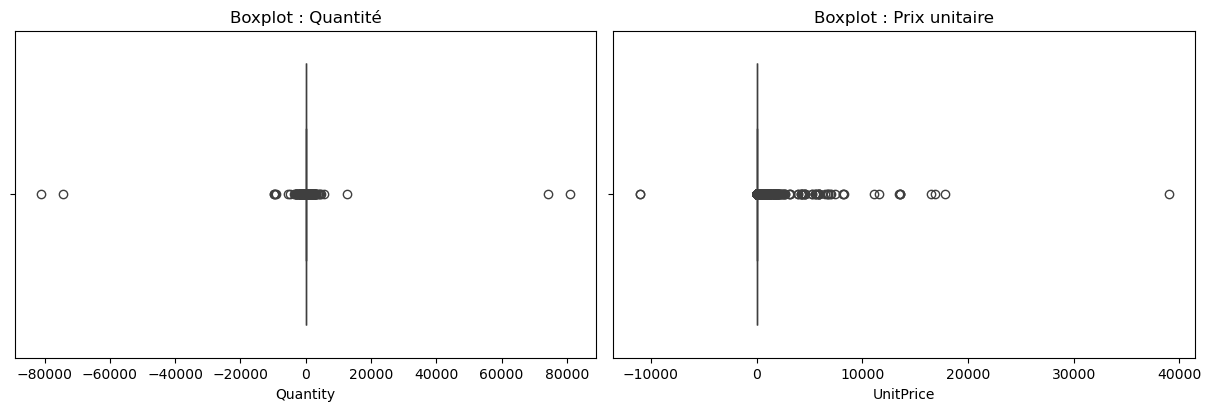

In [19]:
# Boxplots des 2 variables numériques sur une même figure (grille 1 x 2)
# pour repérer les valeurs extrêmes (points au-delà des moustaches)
colonnes = ["Quantity", "UnitPrice"]
titres = ["Quantité", "Prix unitaire"]

# Création de la figure avec 2 graphiques côte à côte
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

# Un boxplot par variable, chacun dans sa case de la grille
for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot : {titre}")

# Affichage
plt.show()

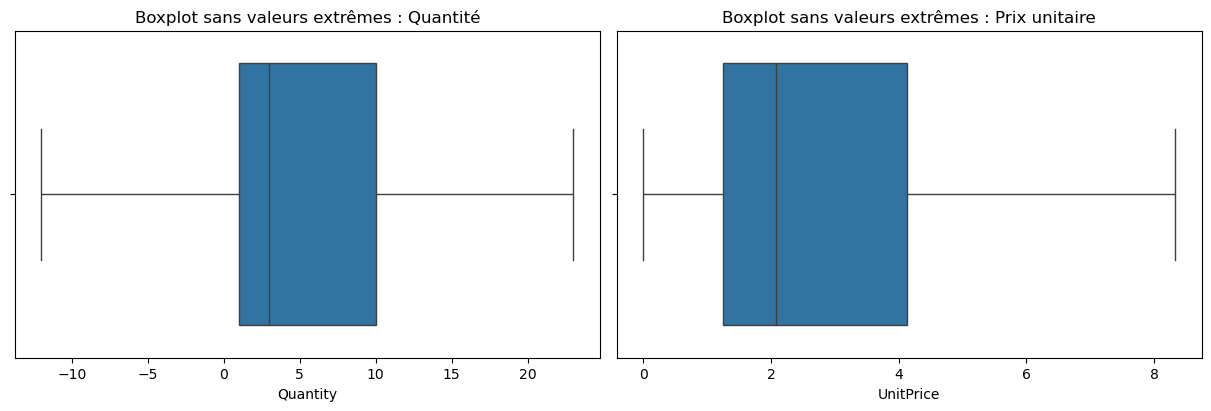

In [20]:
# Boxplots sans les valeurs extrêmes, pour voir la répartition des transactions courantes
colonnes = ["Quantity", "UnitPrice"]
titres = ["Quantité", "Prix unitaire"]

# Création de la figure avec 2 graphiques côte à côte
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

# Un boxplot par variable, sans afficher les points extrêmes
for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.boxplot(x=df[col], ax=ax, showfliers=False)
    ax.set_title(f"Boxplot sans valeurs extrêmes : {titre}")

# Affichage
plt.show()

Les boxplots sont écrasés : la grande majorité des transactions concerne de petites quantités et des prix faibles, regroupés près de 0. Quelques valeurs très extrêmes étirent l'échelle.

Quantité : on observe des valeurs extrêmes dans les deux sens, jusqu'à environ +80 000 et −80 000. Les valeurs positives et négatives semblent se répondre, ce qui laisse penser à de grosses commandes qui ont ensuite été annulées. Les quantités négatives correspondent probablement à des annulations ou des retours.

Prix unitaire : il y a des prix très élevés (jusqu'à environ 40 000) et au moins un prix négatif (environ −10 000). Un prix négatif n'est pas possible pour une vente normale : il s'agit sûrement d'ajustements comptables ou d'erreurs.

Ces valeurs devront être traitées lors du nettoyage, en supprimant les annulations et les prix et quantités négatifs ou nuls.

## 6) Distribution des variables

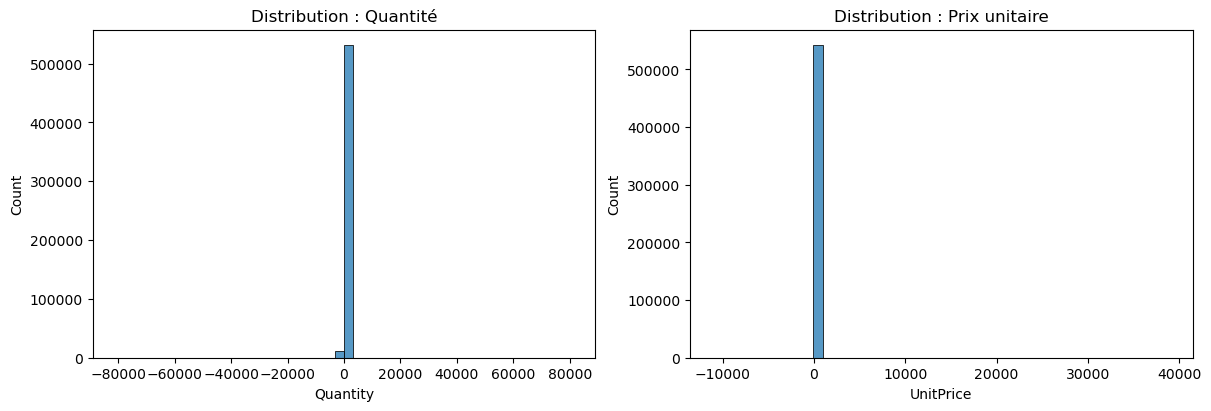

In [21]:
# Histogrammes des 2 variables numériques sur une même figure (grille 1 x 2)
colonnes = ["Quantity", "UnitPrice"]
titres = ["Quantité", "Prix unitaire"]

# Création de la figure avec 2 graphiques côte à côte
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

# Un histogramme par variable, chacun dans sa case de la grille
for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.histplot(x=df[col], bins=50, ax=ax)
    ax.set_title(f"Distribution : {titre}")

# Affichage
plt.show()

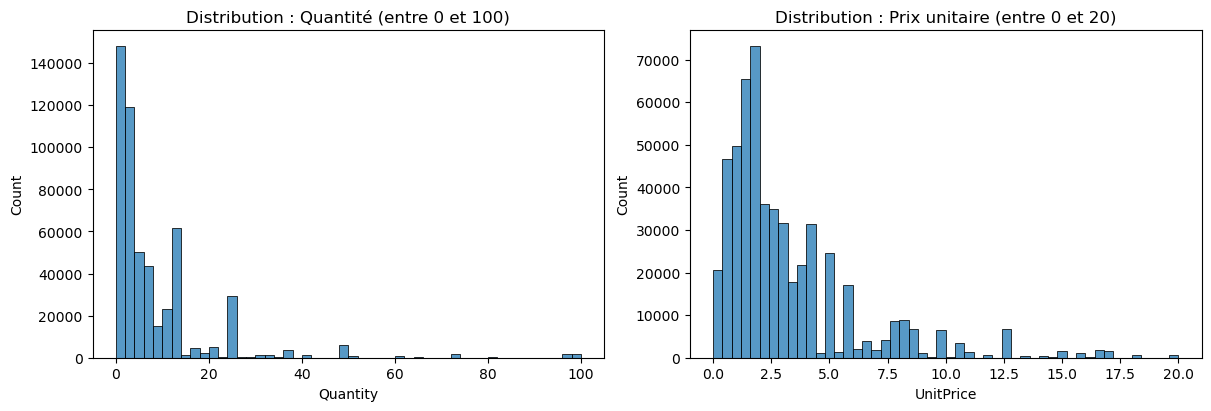

In [22]:
# Création de la figure avec 2 graphiques côte à côte
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

# Histogramme de la quantité, limité aux valeurs entre 0 et 100
sns.histplot(x=df["Quantity"], bins=50, binrange=(0, 100), ax=axs[0])
axs[0].set_title("Distribution : Quantité (entre 0 et 100)")

# Histogramme du prix unitaire, limité aux valeurs entre 0 et 20
sns.histplot(x=df["UnitPrice"], bins=50, binrange=(0, 20), ax=axs[1])
axs[1].set_title("Distribution : Prix unitaire (entre 0 et 20)")

# Affichage
plt.show()

Au niveau des quantités, on remarque que la plupart des transactions portent sur de très petites quantités : entre 1 et 5 articles. La distribution est fortement asymétrique vers la droite : beaucoup de petites commandes et peu de grosses. On observe quelques pics isolés.

En ce qui concerne le prix unitaire, on remarque que la majorité des produits coûte moins de 5, avec un pic autour de 1,5 à 2. Les produits plus chers sont de moins en moins nombreux. La distribution est elle aussi asymétrique vers la droite, avec quelques pics isolés.

Ces deux distributions confirment que le site vend surtout des articles peu chers, en petites quantités ou par lots.

## 7) Analyse des annulations

In [23]:
# Repérage des factures annulées : numéro de facture qui commence par "C"
annulations = df[df["InvoiceNo"].astype(str).str.startswith("C")]

# Nombre de lignes annulées
print("Nombre de lignes annulées :", len(annulations))

# Aperçu des lignes annulées
annulations.head()

Nombre de lignes annulées : 9288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [24]:
# Nombre de lignes annulées
print("Lignes annulées :", len(annulations))

# Nombre de lignes avec une quantité négative
print("Lignes avec une quantité négative :", (df["Quantity"] < 0).sum())

# Nombre de lignes annulées qui ont une quantité négative
print("Annulations avec une quantité négative :", (annulations["Quantity"] < 0).sum())

Lignes annulées : 9288
Lignes avec une quantité négative : 10624
Annulations avec une quantité négative : 9288


Le dataset contient 9 288 lignes annulées, soit environ 1,7 % des transactions. Toutes ces lignes ont une quantité négative : une annulation est enregistrée comme une « vente à l'envers », ce qui explique une grande partie des quantités négatives repérées au point 6.

En revanche, on comptait 10 624 lignes avec une quantité négative, soit environ 1 300 de plus que les annulations. Ces lignes ne sont donc pas des annulations : il peut s'agir d'ajustements de stock ou de corrections. Elles devront aussi être supprimées lors du nettoyage.

Les annulations ne correspondent pas à de vrais achats : il faudra les retirer pour calculer correctement la fréquence et le montant de chaque client.

# Étape 3 : Nettoyage des données

## 1) Suppression des annulations

In [25]:
# Copie du dataset brut pour garder l'original intact
df_clean = df.copy()

# Nombre de lignes avant suppression
print("Avant :", df_clean.shape)

# Conservation des lignes dont le numéro de facture ne commence PAS par "C"
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

# Nombre de lignes après suppression
print("Après :", df_clean.shape)

Avant : (541909, 8)
Après : (532621, 8)


9 288 lignes ont été supprimées, ce qui correspond exactement au nombre d'annulations identifié lors de l'exploration. Toutes les factures annulées ont donc bien été retirées. Il reste 532 621 transactions.

## 2) Gestion des valeurs manquantes dans CustomerID

In [26]:
# Nombre de valeurs manquantes dans CustomerID avant suppression
print("Valeurs manquantes avant :", df_clean["CustomerID"].isnull().sum())

# Suppression des lignes sans CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])

# Vérification : plus aucune valeur manquante dans CustomerID
print("Valeurs manquantes après :", df_clean["CustomerID"].isnull().sum())

# Nombre de lignes restantes
print("Dimensions :", df_clean.shape)

Valeurs manquantes avant : 134697
Valeurs manquantes après : 0
Dimensions : (397924, 8)


134 697 lignes ont été supprimées, soit environ 25 % des transactions restantes. Il reste 397 924 transactions.

C'est une perte importante, mais elle est nécessaire : sans CustomerID, on ne peut pas savoir à quel client appartient l'achat, donc impossible de calculer sa récence, sa fréquence et son montant.

Cette suppression peut toutefois fausser une partie de l'analyse : la segmentation ne portera que sur les clients identifiés. Si les achats sans identifiant ont un profil particulier (par exemple des achats ponctuels sans création de compte), ces clients ne seront pas représentés dans les segments.

## 3) Filtrage des quantités et prix négatifs ou nuls

In [28]:
# Nombre de lignes avant filtrage
print("Avant :", df_clean.shape)

# Conservation des lignes avec une quantité strictement positive
df_clean = df_clean[df_clean["Quantity"] > 0]

# Conservation des lignes avec un prix strictement positif
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Nombre de lignes après filtrage
print("Après :", df_clean.shape)

Avant : (397924, 8)
Après : (397884, 8)


40 lignes ont été supprimées à cette étape. Ce nombre est faible parce que la plupart des quantités négatives avaient déjà été retirées aux étapes précédentes :

- 9 288 étaient des annulations, supprimées au point 1 ;
- les 1 336 autres n'avaient pas de CustomerID et ont été supprimées au point 2.

Les 40 lignes retirées ici correspondent donc sans doute à des prix nuls, par exemple des produits offerts.

## 4) Suppression des doublons

In [31]:
# Nombre de lignes en double
print("Doublons :", df_clean.duplicated().sum())

# Suppression des doublons
df_clean = df_clean.drop_duplicates()

# Nombre de lignes restantes
print("Dimensions :", df_clean.shape)

Doublons : 5192
Dimensions : (392692, 8)


# Étape 4 : Feature engineering RFM (construction et exploration du dataset RFM)

## 1) Création de la colonne Montant

In [33]:
# Calcul du montant de chaque ligne : quantité x prix unitaire
df_clean["Montant"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Vérification sur les premières lignes
df_clean[["Quantity", "UnitPrice", "Montant"]].head()

,Quantity,UnitPrice,Montant
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 2) Choix de la date de référence

In [34]:
# Vérification du type de la colonne InvoiceDate (doit être datetime64)
print(df_clean["InvoiceDate"].dtype)

# Date de la dernière transaction du dataset
print("Dernière transaction :", df_clean["InvoiceDate"].max())

# Date de référence : le lendemain de la dernière transaction
date_reference = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Date de référence :", date_reference)

datetime64[ns]
Dernière transaction : 2011-12-09 12:50:00
Date de référence : 2011-12-10 12:50:00


## 3) Agrégation par CustomerID

In [35]:
# Regroupement des transactions par client
rfm = df_clean.groupby("CustomerID").agg(
    # Date du dernier achat du client
    Recence=("InvoiceDate", "max"),
    # Nombre de factures différentes du client
    Frequence=("InvoiceNo", "nunique"),
    # Total dépensé par le client
    Montant=("Montant", "sum"),
)

# Transformation de la date du dernier achat en nombre de jours avant la date de référence
rfm["Recence"] = (date_reference - rfm["Recence"]).dt.days

# Nombre de clients obtenus
print("Dimensions :", rfm.shape)

Dimensions : (4338, 3)


Le dataset RFM contient 4 338 clients, chacun décrit par sa récence, sa fréquence et son montant.

La fréquence compte les factures différentes plutôt que les lignes, car une facture contient une ligne par produit acheté. Un client qui achète 10 produits en une seule commande aurait 10 lignes, mais une seule commande. Compter les lignes mesurerait le nombre de produits achetés, pas le nombre de fois où le client est venu acheter.

## 4) Aperçu du dataset RFM

In [36]:
# Affichage des 10 premiers clients
rfm.head(10)

,Recence,Frequence,Montant
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


## 5) Statistiques descriptives

In [37]:
# Statistiques descriptives de la Récence, de la Fréquence et du Montant
rfm.describe().round(2)

,Recence,Frequence,Montant
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


Récence : la moyenne est de 93 jours et la médiane de 51 jours. La moitié des clients a acheté il y a moins de 2 mois, mais certains n'ont rien acheté depuis plus d'un an (maximum de 374 jours).

Fréquence : la moyenne est de 4,3 commandes et la médiane de 2. La moitié des clients a passé au plus 2 commandes, et un quart n'en a passé qu'une seule. Quelques clients sont très fidèles, jusqu'à 209 commandes.

Montant : la moyenne est de 2 049 et la médiane de 669. La moitié des clients a dépensé moins de 669, mais un client atteint plus de 280 000.

Pour les trois métriques, la moyenne est nettement supérieure à la médiane, surtout pour la fréquence et le montant (environ 3 fois plus). Cela révèle des distributions fortement asymétriques vers la droite : la majorité des clients a des valeurs faibles, et un petit nombre de clients a des valeurs très élevées qui tirent la moyenne vers le haut. Cette asymétrie justifie la transformation logarithmique prévue dans le prétraitement.

## 6) Exploration des valeurs aberrantes

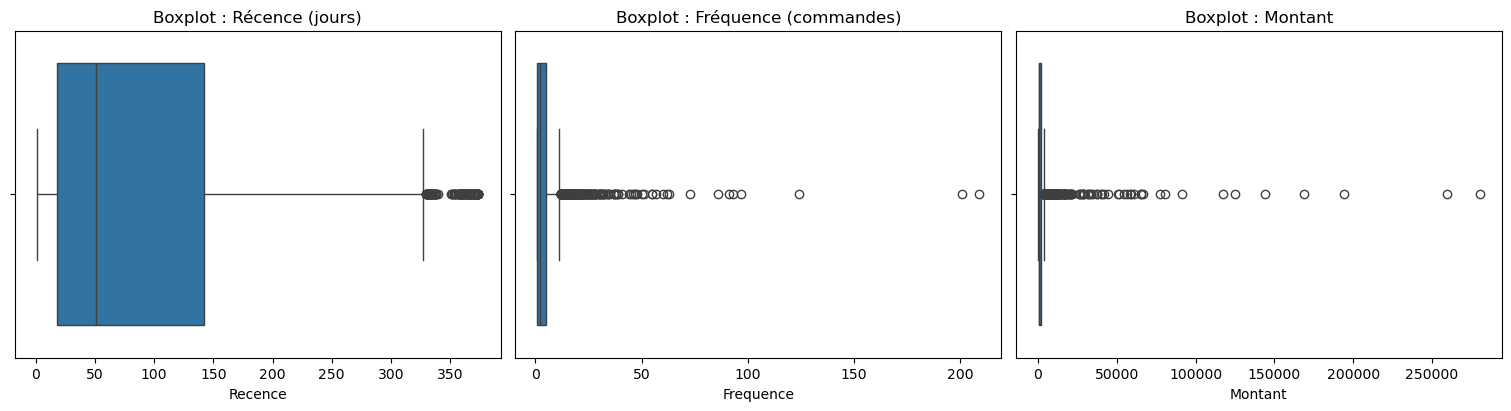

In [38]:
# Boxplots des 3 métriques RFM sur une même figure (grille 1 x 3)
# pour repérer les valeurs extrêmes (points au-delà des moustaches)
colonnes = ["Recence", "Frequence", "Montant"]
titres = ["Récence (jours)", "Fréquence (commandes)", "Montant"]

# Création de la figure avec 3 graphiques côte à côte
fig, axs = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")

# Un boxplot par métrique, chacun dans sa case de la grille
for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.boxplot(x=rfm[col], ax=ax)
    ax.set_title(f"Boxplot : {titre}")

# Affichage
plt.show()

- Récence : la boîte est bien visible. La moitié des clients a acheté il y a entre 20 et 140 jours. Quelques valeurs extrêmes apparaissent au-delà d'environ 340 jours : ce sont des clients qui n'ont rien acheté depuis presque un an. Ce ne sont pas des erreurs, mais des clients inactifs, potentiellement perdus.

- Fréquence : la boîte est écrasée près de 0, car la plupart des clients ont passé entre 1 et 5 commandes. On observe de nombreuses valeurs extrêmes au-delà de 10 commandes, jusqu'à plus de 200.

- Montant : même constat, la boîte est écrasée près de 0. De nombreux clients dépassent les moustaches, et quelques-uns atteignent plus de 250 000.

Ces valeurs extrêmes ne sont pas des erreurs : le nettoyage a déjà retiré les annulations, les prix et quantités négatifs, ainsi que les doublons. Il s'agit de clients réels au comportement particulier, probablement des clients professionnels ou des grossistes qui commandent souvent et en grande quantité. Ce sont les clients les plus précieux pour l'entreprise : il faut donc les conserver. La transformation logarithmique permettra de réduire leur influence sur le clustering.

## 7) Distribution des variables

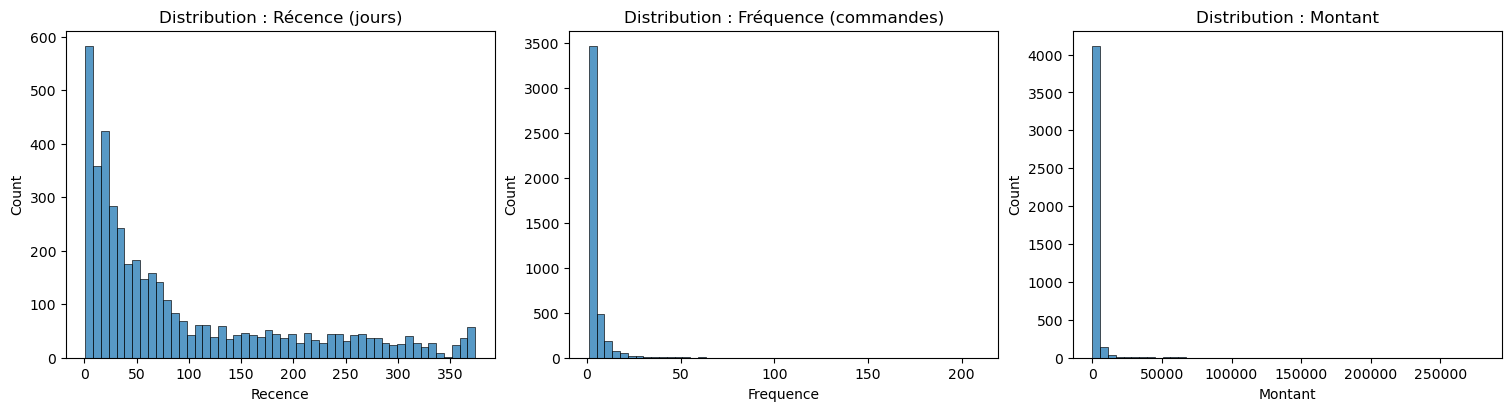

In [39]:
# Histogrammes des 3 métriques RFM sur une même figure (grille 1 x 3)
colonnes = ["Recence", "Frequence", "Montant"]
titres = ["Récence (jours)", "Fréquence (commandes)", "Montant"]

# Création de la figure avec 3 graphiques côte à côte
fig, axs = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")

# Un histogramme par métrique, chacun dans sa case de la grille
for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.histplot(x=rfm[col], bins=50, ax=ax)
    ax.set_title(f"Distribution : {titre}")

# Affichage
plt.show()

- Récence : beaucoup de clients ont acheté récemment : le pic se situe entre 0 et 50 jours. Le nombre de clients diminue ensuite jusqu'à environ 100 jours, puis reste faible et assez stable jusqu'à 374 jours. La distribution est asymétrique vers la droite.

- Fréquence : la grande majorité des clients (environ 3 500 sur 4 338) se trouve dans la première barre, avec seulement quelques commandes. Une longue traîne s'étire jusqu'à plus de 200 commandes. La distribution est très fortement asymétrique vers la droite.

- Montant : même constat. Presque tous les clients (environ 4 100) sont dans la première barre, et quelques clients s'étalent jusqu'à plus de 250 000. La distribution est elle aussi très fortement asymétrique vers la droite.

Ces asymétries posent problème pour le clustering : K-means repose sur des distances, et les quelques clients aux valeurs très élevées domineraient les calculs. C'est pourquoi on appliquera une transformation logarithmique, pour resserrer ces écarts avant la standardisation.

## 8) Analyse des corrélations

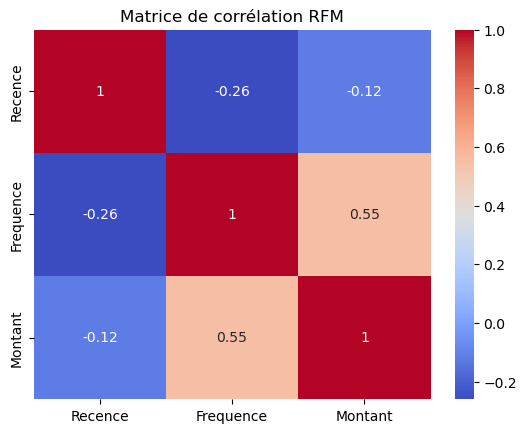

In [40]:
# Matrice de corrélation entre les 3 métriques RFM
corr = rfm.corr()

# Heatmap de la matrice de corrélation
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation RFM")
plt.show()

On observe une corrélation positive forte entre la fréquence et le montant (+0,55). Cela suggère que les clients qui commandent souvent sont ceux qui dépensent le plus au total, ce qui est logique.

La récence est négativement corrélée à la fréquence (−0,26). Ainsi, les clients qui n'ont pas acheté depuis longtemps ont en général passé moins de commandes. À l'inverse, les clients qui ont acheté récemment sont aussi ceux qui achètent le plus souvent.

La corrélation entre la récence et le montant est faible (−0,12). Par conséquent, les clients inactifs depuis longtemps ont dépensé un peu moins au total.

Pour le clustering, la fréquence et le montant apportent en partie la même information. Leur corrélation n'est cependant pas assez forte pour justifier de supprimer l'une des deux : chaque métrique garde un apport propre, on conserve donc les trois.

# Étape 5 : Prétraitement

## 1) Sélection des variables

In [42]:
# Sélection des 3 métriques RFM pour le clustering
X = rfm[["Recence", "Frequence", "Montant"]]

# Aperçu des variables sélectionnées
X.head()

,Recence,Frequence,Montant
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## 2) Encodage des variables catégorielles, si nécessaire

In [43]:
# Vérification du type des variables sélectionnées
X.dtypes

Recence        int64
Frequence      int64
Montant      float64
dtype: object

Aucun encodage n'est nécessaire : les trois variables sélectionnées sont déjà numériques.

## 3) Détection et gestion des valeurs aberrantes

In [44]:
# Comptage des valeurs extrêmes de chaque métrique avec la règle IQR
colonnes = ["Recence", "Frequence", "Montant"]

for col in colonnes:
    # Calcul des quartiles et de la borne haute
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    seuil = q3 + 1.5 * (q3 - q1)
    # Nombre de clients au-dessus de la borne haute
    nb = (X[col] > seuil).sum()
    print(f"{col} : borne haute = {seuil:.2f}, {nb} clients au-dessus")

Recence : borne haute = 328.00, 155 clients au-dessus
Frequence : borne haute = 11.00, 285 clients au-dessus
Montant : borne haute = 3691.77, 425 clients au-dessus


- Récence : 155 clients dépassent la borne haute de 328 jours, soit environ 3,6 % des clients. Ce sont des clients qui n'ont rien acheté depuis presque un an.

- Fréquence : 285 clients ont passé plus de 11 commandes, soit environ 6,6 % des clients.

- Montant : 425 clients ont dépensé plus de 3 692, soit environ 9,8 % des clients.

Ces valeurs extrêmes sont conservées. Ce ne sont pas des erreurs, puisque les données ont déjà été nettoyées : ce sont des clients réels. Les supprimer reviendrait à retirer près de 10 % des clients, et surtout les plus fidèles et les plus rentables (fréquence et montant élevés), ou les clients inactifs (récence élevée). Ce sont justement des segments intéressants pour le marketing. La transformation logarithmique permettra de réduire leur influence sur le clustering.

## 4) Transformation logarithmique

In [46]:
# Application de la transformation logarithmique aux 3 métriques
X_log = np.log1p(X)

# Aperçu des valeurs transformées
X_log.head()

,Recence,Frequence,Montant
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


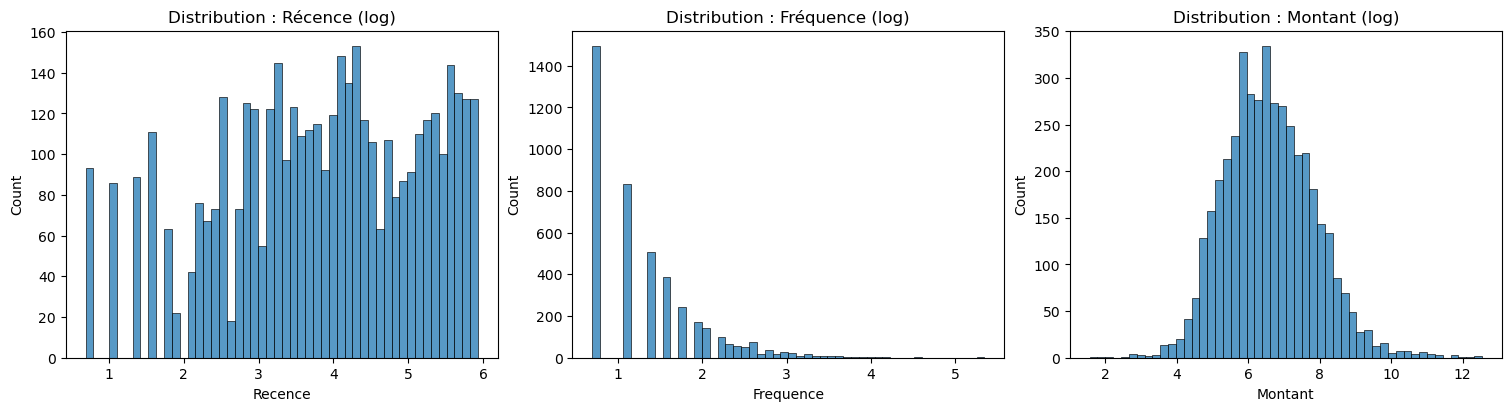

In [47]:
# Histogrammes des 3 métriques après transformation (grille 1 x 3)
colonnes = ["Recence", "Frequence", "Montant"]
titres = ["Récence (log)", "Fréquence (log)", "Montant (log)"]

# Création de la figure avec 3 graphiques côte à côte
fig, axs = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")

# Un histogramme par métrique, chacun dans sa case de la grille
for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.histplot(x=X_log[col], bins=50, ax=ax)
    ax.set_title(f"Distribution : {titre}")

# Affichage
plt.show()

- Montant : c'est la transformation la plus réussie. La distribution, très asymétrique au départ, a maintenant une forme de cloche presque symétrique, centrée autour de 6,5.

- Fréquence : l'asymétrie est nettement réduite, mais elle reste visible vers la droite. Les barres isolées à gauche s'expliquent par le fait que la fréquence est un nombre entier : 1 commande devient 0,69, 2 commandes deviennent 1,10, et ainsi de suite. La première barre, la plus haute (environ 1 500 clients), correspond aux clients qui n'ont passé qu'une seule commande.

- Récence : la distribution s'est inversée. Elle penche maintenant légèrement vers la gauche : le logarithme a resserré les grandes valeurs (clients inactifs) et étiré les petites (clients récents). Les barres isolées à gauche correspondent aux tout premiers jours (1, 2, 3 jours…), qui sont des nombres entiers. La répartition est cependant plus équilibrée qu'avant.

La transformation logarithmique est utile avant le clustering, car elle réduit les écarts énormes entre clients. Sans elle, les quelques clients aux fréquences et montants très élevés domineraient les calculs de distance de K-means, et la plupart des autres clients seraient regroupés ensemble. Après transformation, les trois métriques sont plus comparables, et chaque client compte de façon plus équilibrée dans la formation des clusters. Ainsi, le logarithme réduit l'asymétrie à l'intérieur de chaque variable.

## 5) Standardisation des variables

In [48]:
# Import de la classe StandardScaler
from sklearn.preprocessing import StandardScaler

# Création du scaler
scaler = StandardScaler()

# Standardisation des 3 métriques transformées par le logarithme
X_scaled = pd.DataFrame(scaler.fit_transform(X_log), columns=X_log.columns, index=X_log.index)

# Vérification : moyenne proche de 0 et écart-type proche de 1
X_scaled.describe().round(2)

,Recence,Frequence,Montant
count,4338.00,4338.00,4338.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.07
75%,0.84,0.65,0.66
max,1.56,5.86,4.73


Après standardisation, les trois métriques ont une moyenne de 0 et un écart-type de 1 : elles sont maintenant à la même échelle et auront le même poids dans le calcul des distances du clustering.

## 6) Aperçu du dataset final après prétraitement

In [50]:
# Dimensions du dataset final
print(X_scaled.shape)

# Aperçu des premières lignes
X_scaled.head()

(4338, 3)


,Recence,Frequence,Montant
CustomerID,,,
12346.0,1.461993,-0.955214,3.707716
12347.0,-2.038734,1.074425,1.414903
12348.0,0.373104,0.386304,0.720024
12349.0,-0.623086,-0.955214,0.702287
12350.0,1.424558,-0.955214,-0.614514


In [51]:
# Enregistrement du dataset RFM (valeurs réelles, pour interpréter les clusters)
rfm.to_csv("rfm.csv")

# Enregistrement du dataset prétraité (pour le clustering)
X_scaled.to_csv("rfm_scaled.csv")